# 5. BO

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

import lightgbm as lgb

from rdkit import Chem
from rdkit.Chem import Draw

import optuna
import joblib
import os

from scipy.stats import norm
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel, Matern, DotProduct
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## データ読み込み

### 学習データ

In [2]:
# 入力：読み込みたい記述子のタイプを選択
descriptor_type = "mordred_3d"  # 'rdkit' or 'mordred_2d' or 'mordred_3d' or 'fp'

dataset_train = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset_train[["Emission max (nm)", "Quantum yield"]]

if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0
    )
elif descriptor_type == "mordred_3d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0
    )
elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 目的変数と記述子を結合
dataset = target.join(des, how="inner")
print(target.shape, des.shape, dataset.shape)

(13132, 2) (13132, 1382) (13132, 1384)


In [3]:
# データを1000個程度に絞る（GPR は計算量が O(n^3) 級のため件数を制限）
MAX_SAMPLES = 1000
RANDOM_STATE = 1234

if len(dataset) > MAX_SAMPLES:
    dataset = dataset.sample(n=MAX_SAMPLES, random_state=RANDOM_STATE)
    print(f"dataset を {MAX_SAMPLES} 件に間引き: {dataset.shape}")
else:
    print(f"件数 ≤ {MAX_SAMPLES} のためそのまま利用: {dataset.shape}")

dataset を 1000 件に間引き: (1000, 1384)


In [4]:
dataset.head()

,Emission max (nm),Quantum yield,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Tag,,,,,,,,,,,,,,,,,,,,,
10561,419.0,0.1552,0,0,66.155768,2.434636,4.837542,66.155768,1.350118,4.844559,...,10.837874,103.403041,678.187166,8.584648,10754,80,270.0,322.0,11.527778,10.666667
18142,479.0,0.1000,0,0,25.122064,2.372776,4.745552,25.122064,1.256103,3.861266,...,9.504576,52.369969,282.110338,7.423956,900,27,88.0,98.0,7.444444,5.055556
147,483.0,0.6900,0,0,35.557533,2.585511,5.171023,35.557533,1.367597,4.228432,...,10.517889,61.906928,338.105528,8.452638,1473,50,148.0,183.0,6.611111,5.583333
2640,329.0,0.1300,0,0,20.422216,2.384106,4.671950,20.422216,1.361481,3.666520,...,9.564863,55.243789,195.104799,6.968029,334,25,80.0,94.0,3.194444,3.305556
11097,469.0,0.0137,0,0,38.989491,2.489618,4.884380,38.989491,1.344465,4.301290,...,10.302431,78.591952,384.172545,7.248539,2165,48,152.0,182.0,8.250000,6.666667


### テストデータ

In [5]:
# 入力：読み込みたい記述子のタイプを選択
descriptor_type = "mordred_3d"  # 'rdkit' or 'mordred_2d' or 'mordred_3d' or 'fp'

# dataset = pd.read_csv("../data/dataset_test.csv", index_col=0)

if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0
    )
elif descriptor_type == "mordred_3d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0
    )
elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 目的変数と記述子を結合
x_prediction = des
print(des.shape, x_prediction.shape)

(7104, 1382) (7104, 1382)


## GPR

In [6]:
# データ分割
target = 'Emission max (nm)'  # or 'Quantum yield'

y = dataset[target]  # 目的変数
x = dataset.drop(columns=['Emission max (nm)', 'Quantum yield'])  # 説明変数（残り全部）

In [7]:
# 標準偏差が 0 の特徴量の削除
deleting_variables = x.columns[x.std() == 0]
x = x.drop(deleting_variables, axis=1)
x_prediction = x_prediction.drop(deleting_variables, axis=1)
cumulative_variance = np.zeros(x_prediction.shape[0]) # MI で必要な "ばらつき" を 0 で初期化

In [8]:
x.shape, x_prediction.shape

((1000, 1335), (7104, 1335))

In [9]:
# カーネル 11 種類
kernels = [ConstantKernel() * DotProduct() + WhiteKernel(),
           ConstantKernel() * RBF() + WhiteKernel(),
           ConstantKernel() * RBF() + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel(),
           ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=1.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=0.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=2.5) + WhiteKernel() + ConstantKernel() * DotProduct()]

# GPR のハイパーパラメータ
number_of_selecting_samples = 5  # 選択するサンプル数
regression_method = 'gpr_one_kernel'  # gpr_one_kernel', 'gpr_kernels'
acquisition_function = 'PTR'  # 'PTR', 'PI', 'EI', 'MI'

fold_number = 10  # クロスバリデーションの fold 数
kernel_number = 7  # 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
target_range = [600, 1000]  # PTR
relaxation = 0.01  # EI, PI
delta = 10 ** -6  # MI

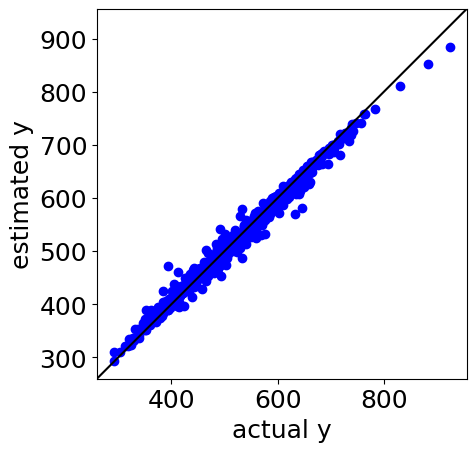

r^2 for training data : 0.9857405394490679
RMSE for training data : 11.080270639928806
MAE for training data : 7.558806606820439


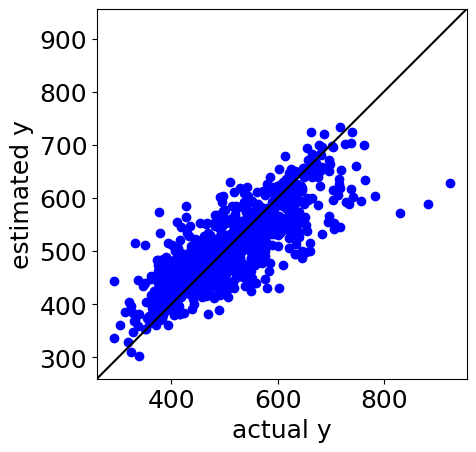

r^2 in cross-validation : 0.6599901745280574
RMSE in cross-validation : 54.10589108595599
MAE in cross-validation : 39.344705837351206


/tmp/ipykernel_84054/160970689.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  next_samples = pd.concat([next_samples, new_row], axis=0)


sample number : 1 / 5
sample number : 2 / 5
sample number : 3 / 5
sample number : 4 / 5
sample number : 5 / 5


In [10]:
# Bayesian optimization
save_dir = "outputs/result/bo"  # 保存先を指定
os.makedirs(save_dir, exist_ok=True)
target_label = target.replace(" ", "_").replace("(", "").replace(")", "")

# 次のサンプル（記述子 + 各ラウンドの y 予測・標準偏差・獲得関数）
next_samples = pd.DataFrame(
    columns=list(x_prediction.columns)
    + ["y_prediction", "y_std", "acquisition_function"]
)

for sample_number in range(number_of_selecting_samples):
    # ===== 1) 学習データ・候補データのオートスケーリング =====
    # 毎ラウンドで、現時点の x, y を基準にスケーリングし直す
    autoscaled_y = (y - y.mean()) / y.std()
    autoscaled_x = (x - x.mean()) / x.std()
    autoscaled_x_prediction = (x_prediction - x.mean()) / x.std()
    
    # ===== 2) GPR モデル構築（単一カーネル or CVでカーネル選択） =====
    if regression_method == 'gpr_one_kernel':
        selected_kernel = kernels[kernel_number]
        model = GaussianProcessRegressor(alpha=0, kernel=selected_kernel)
    elif regression_method == 'gpr_kernels':
        # クロスバリデーションで候補カーネルを比較し、r2 が最大のものを採用
        cross_validation = KFold(n_splits=fold_number, random_state=9, shuffle=True) # クロスバリデーションの分割の設定
        r2cvs = [] # 空の list。カーネル関数ごとに、クロスバリデーション後の r2 を入れていきます
        for index, kernel in enumerate(kernels):
            print(index + 1, '/', len(kernels))
            model = GaussianProcessRegressor(alpha=0, kernel=kernel)
            # cross_val_predict は各サンプルに対する out-of-fold 予測を返す
            # （最初/最後の fold の予測だけを使うのではなく、全 fold 分を結合した1本の予測ベクトル）
            estimated_y_in_cv = np.ndarray.flatten(cross_val_predict(model, autoscaled_x, autoscaled_y, cv=cross_validation))
            estimated_y_in_cv = estimated_y_in_cv * y.std(ddof=1) + y.mean()
            r2cvs.append(r2_score(y, estimated_y_in_cv))
        optimal_kernel_number = np.where(r2cvs == np.max(r2cvs))[0][0]  # クロスバリデーション後の r2 が最も大きいカーネル関数の番号
        optimal_kernel = kernels[optimal_kernel_number]  # クロスバリデーション後の r2 が最も大きいカーネル関数
        print('クロスバリデーションで選択されたカーネル関数の番号 :', optimal_kernel_number)
        print('クロスバリデーションで選択されたカーネル関数 :', optimal_kernel)
        
        # モデル構築
        model = GaussianProcessRegressor(alpha=0, kernel=optimal_kernel) # GPR モデルの宣言
    
    # ===== 3) モデル学習 =====
    model.fit(autoscaled_x, autoscaled_y)  
    
    # 初回ラウンドのみ、モデル診断（yyplot・指標・詳細csv）を保存
    if sample_number == 0:
        # 3-1) トレーニングデータの推定
        autoscaled_estimated_y, autoscaled_estimated_y_std = model.predict(autoscaled_x, return_std=True)  # y の推定
        estimated_y = autoscaled_estimated_y * y.std() + y.mean()  # スケールをもとに戻す
        estimated_y_std = autoscaled_estimated_y_std * y.std()  # スケールをもとに戻す
        estimated_y = pd.DataFrame(estimated_y, index=x.index, columns=['estimated_y'])
        estimated_y_std = pd.DataFrame(estimated_y_std, index=x.index, columns=['std_of_estimated_y'])
        
        # トレーニングデータの実測値 vs. 推定値のプロット ← 事前にyyplotとして関数化しておいていいかも
        plt.rcParams['font.size'] = 18
        plt.scatter(y, estimated_y.iloc[:, 0], c='blue')  # 実測値 vs. 推定値プロット
        y_max = max(y.max(), estimated_y.iloc[:, 0].max())  # 実測値の最大値と、推定値の最大値の中で、より大きい値を取得
        y_min = min(y.min(), estimated_y.iloc[:, 0].min())  # 実測値の最小値と、推定値の最小値の中で、より小さい値を取得
        plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
                 [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-')  # 取得した最小値-5%から最大値+5%まで、対角線を作成
        plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # y 軸の範囲の設定
        plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # x 軸の範囲の設定
        plt.xlabel('actual y')  # x 軸の名前
        plt.ylabel('estimated y')  # y 軸の名前
        plt.gca().set_aspect('equal', adjustable='box')  # 図の形を正方形に
        plt.show()  # 以上の設定で描画
        
        # トレーニングデータのr2, RMSE, MAE
        print('r^2 for training data :', r2_score(y, estimated_y))
        rmse_train = np.sqrt(mean_squared_error(y, estimated_y))
        print('RMSE for training data :', rmse_train)
        print('MAE for training data :', mean_absolute_error(y, estimated_y))
        
        # トレーニングデータの結果の保存
        y_for_save = pd.DataFrame(y)
        y_for_save.columns = ['actual_y']
        y_error_train = y_for_save.iloc[:, 0] - estimated_y.iloc[:, 0]
        y_error_train = pd.DataFrame(y_error_train)
        y_error_train.columns = ['error_of_y(actual_y-estimated_y)']
        results_train = pd.concat([y_for_save, estimated_y, y_error_train, estimated_y_std], axis=1) # 結合
        results_train.to_csv(f"{save_dir}/estimated_y_in_detail_{target_label}_{regression_method}.csv")  # 推定値を csv ファイルに保存。同じ名前のファイルがあるときは上書きされますので注意してください
        
        # 3-2) クロスバリデーションによる y 推定（OOF予測）
        cross_validation = KFold(n_splits=fold_number, random_state=9, shuffle=True) # 例: fold_number=10 なら 10-fold CV
        # ここでの予測は「各サンプルがそのサンプルを学習に使っていない fold モデルで予測された値（OOF）」
        # したがって yyplot は「最初のfoldだけ」「最後のfoldだけ」ではなく、全サンプル分の OOF 予測を描画
        autoscaled_estimated_y_in_cv = cross_val_predict(model, autoscaled_x, autoscaled_y, cv=cross_validation)  # y の推定
        estimated_y_in_cv = autoscaled_estimated_y_in_cv * y.std() + y.mean()  # スケールをもとに戻す
        estimated_y_in_cv = pd.DataFrame(estimated_y_in_cv, index=x.index, columns=['estimated_y'])
        
        # クロスバリデーションにおける実測値 vs. 推定値のプロット
        plt.rcParams['font.size'] = 18
        plt.scatter(y, estimated_y_in_cv.iloc[:, 0], c='blue')  # 実測値 vs. 推定値プロット
        y_max = max(y.max(), estimated_y_in_cv.iloc[:, 0].max())  # 実測値の最大値と、推定値の最大値の中で、より大きい値を取得
        y_min = min(y.min(), estimated_y_in_cv.iloc[:, 0].min())  # 実測値の最小値と、推定値の最小値の中で、より小さい値を取得
        plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
                 [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-')  # 取得した最小値-5%から最大値+5%まで、対角線を作成
        plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # y 軸の範囲の設定
        plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # x 軸の範囲の設定
        plt.xlabel('actual y')  # x 軸の名前
        plt.ylabel('estimated y')  # y 軸の名前
        plt.gca().set_aspect('equal', adjustable='box')  # 図の形を正方形に
        plt.show()  # 以上の設定で描画
        
        # クロスバリデーションにおけるr2, RMSE, MAE
        print('r^2 in cross-validation :', r2_score(y, estimated_y_in_cv))
        rmse_cv = np.sqrt(mean_squared_error(y, estimated_y_in_cv))
        print('RMSE in cross-validation :', rmse_cv)
        print('MAE in cross-validation :', mean_absolute_error(y, estimated_y_in_cv))
        
        # クロスバリデーションの結果の保存
        y_error_in_cv = y_for_save.iloc[:, 0] - estimated_y_in_cv.iloc[:, 0]
        y_error_in_cv = pd.DataFrame(y_error_in_cv)
        y_error_in_cv.columns = ['error_of_y(actual_y-estimated_y)']
        results_in_cv = pd.concat([y_for_save, estimated_y_in_cv, y_error_in_cv], axis=1) # 結合
        results_in_cv.to_csv(f"{save_dir}/estimated_y_in_cv_in_detail_{target_label}_{regression_method}.csv")  # 推定値を csv ファイルに保存。同じ名前のファイルがあるときは上書きされますので注意してください
    
    # ===== 4) 候補点 x_prediction に対する予測 =====
    estimated_y_prediction, estimated_y_prediction_std = model.predict(autoscaled_x_prediction, return_std=True)
    estimated_y_prediction = estimated_y_prediction * y.std() + y.mean()
    estimated_y_prediction_std = estimated_y_prediction_std * y.std()
    
    # ===== 5) 獲得関数の計算（MI / EI / PI / PTR） =====
    if acquisition_function == 'MI':
        acquisition_function_prediction = estimated_y_prediction + np.log(2 / delta) ** 0.5 * (
                (estimated_y_prediction_std ** 2 + cumulative_variance) ** 0.5 - cumulative_variance ** 0.5)
        cumulative_variance = cumulative_variance + estimated_y_prediction_std ** 2
    elif acquisition_function == 'EI':
        acquisition_function_prediction = (estimated_y_prediction - max(y) - relaxation * y.std()) * \
                                           norm.cdf((estimated_y_prediction - max(y) - relaxation * y.std()) /
                                                     estimated_y_prediction_std) + \
                                           estimated_y_prediction_std * \
                                           norm.pdf((estimated_y_prediction - max(y) - relaxation * y.std()) /
                                                     estimated_y_prediction_std)
    elif acquisition_function == 'PI':
        acquisition_function_prediction = norm.cdf(
                (estimated_y_prediction - max(y) - relaxation * y.std()) / estimated_y_prediction_std)
    elif acquisition_function == 'PTR':
        acquisition_function_prediction = norm.cdf(target_range[1],
                                                   loc=estimated_y_prediction,
                                                   scale=estimated_y_prediction_std
                                                   ) - norm.cdf(target_range[0],
                                                                loc=estimated_y_prediction,
                                                                scale=estimated_y_prediction_std)
    acquisition_function_prediction[estimated_y_prediction_std <= 0] = 0
    
    # ===== 6) 予測結果・獲得関数の DataFrame 化と保存 =====
    estimated_y_prediction = pd.DataFrame(estimated_y_prediction, x_prediction.index, columns=['estimated_y'])
    estimated_y_prediction_std = pd.DataFrame(estimated_y_prediction_std, x_prediction.index, columns=['std_of_estimated_y'])
    acquisition_function_prediction = pd.DataFrame(acquisition_function_prediction, index=x_prediction.index, columns=['acquisition_function'])
    if sample_number == 0:
        estimated_y_prediction.to_csv(f"{save_dir}/estimated_y_prediction_{target_label}_{regression_method}.csv")  # 予測結果を csv ファイルに保存。同じ名前のファイルがあるときは上書きされますので注意してください
        estimated_y_prediction_std.to_csv(f"{save_dir}/estimated_y_prediction_{target_label}_{regression_method}_std.csv")  # 予測値の標準偏差を csv ファイルに保存。同じ名前のファイルがあるときは上書きされますので注意してください
        acquisition_function_prediction.to_csv(f"{save_dir}/acquisition_function_prediction_{target_label}_{regression_method}_{acquisition_function}.csv")  # 獲得関数を csv ファイルに保存。同じ名前のファイルがあるときは上書きされますので注意してください

    # ===== 7) 次に実験するサンプルを選択（獲得関数最大） =====
    # 記述子と予測情報を同一行に保持して、履歴 next_samples に追加
    # 1列 DataFrame の idxmax() は Series を返すため、スカラーTagは Series 側で取得
    selected_idx = acquisition_function_prediction.iloc[:, 0].idxmax()
    new_row = x_prediction.loc[[selected_idx]].copy()
    new_row["y_prediction"] = float(
        estimated_y_prediction.loc[selected_idx, "estimated_y"]
    )
    new_row["y_std"] = float(
        estimated_y_prediction_std.loc[selected_idx, "std_of_estimated_y"]
    )
    new_row["acquisition_function"] = float(
        acquisition_function_prediction.loc[selected_idx, "acquisition_function"]
    )
    next_samples = pd.concat([next_samples, new_row], axis=0)

    # ===== 8) 学習データ・候補集合を更新し、次ラウンドへ =====
    # 選ばれた点を x/y に取り込み、候補集合 x_prediction からは削除
    x = pd.concat([x, x_prediction.loc[[selected_idx]]], axis=0)
    y = pd.concat(
        [y, estimated_y_prediction.loc[[selected_idx], "estimated_y"]], axis=0
    )
    x_prediction = x_prediction.drop(selected_idx, axis=0)
    cumulative_variance = np.delete(
        cumulative_variance,
        np.where(acquisition_function_prediction.index == selected_idx)[0][0],
    )
    print('sample number : {0} / {1}'.format(sample_number + 1, number_of_selecting_samples))

## 結果

In [11]:
next_samples

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,...,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,y_prediction,y_std,acquisition_function
7560,0,0,121.123529,2.761284,5.437756,121.123529,1.274985,5.509586,6.314900,0.066473,...,6.194517,47609,191,550.0,679.0,32.569444,19.666667,811.130774,31.537527,1.000000
7557,0,0,114.404318,2.734685,5.327018,114.404318,1.395175,5.407188,7.020733,0.085619,...,8.126977,29766,186,508.0,657.0,18.312500,17.000000,766.783816,32.196829,1.000000
16295,0,0,93.074549,2.741527,5.380700,93.074549,1.310909,5.220181,6.402652,0.090178,...,7.825532,19148,166,410.0,530.0,25.729167,16.000000,757.465798,32.547434,0.999999
16293,0,0,93.074549,2.741527,5.380700,93.074549,1.310909,5.220181,6.402652,0.090178,...,7.825532,19148,166,410.0,530.0,25.729167,16.000000,756.228754,33.040434,0.999999
16297,0,0,93.074549,2.741527,5.380700,93.074549,1.310909,5.220181,6.402652,0.090178,...,7.825532,19148,166,410.0,530.0,25.729167,16.000000,754.977222,30.515280,1.000000


In [12]:
# next_samplesのy予測値、yのstd、獲得関数の値をまとめて、pd.DataFrameにする
next_samples_df = next_samples[
    ["y_prediction", "y_std", "acquisition_function"]
]

next_samples_df

,y_prediction,y_std,acquisition_function
7560,811.130774,31.537527,1.000000
7557,766.783816,32.196829,1.000000
16295,757.465798,32.547434,0.999999
16293,756.228754,33.040434,0.999999
16297,754.977222,30.515280,1.000000


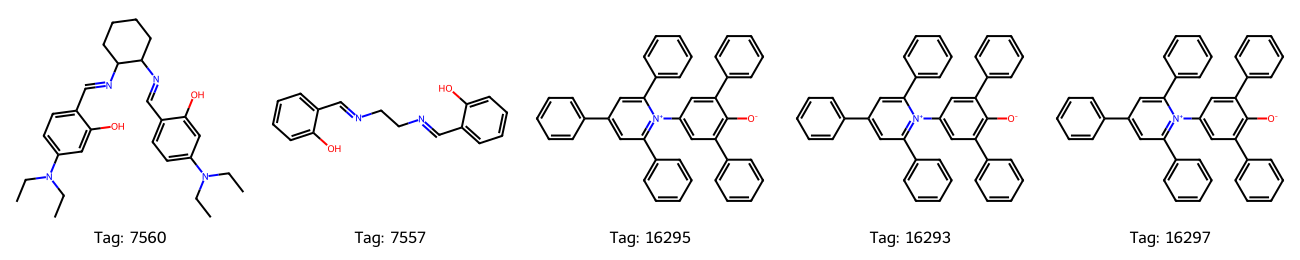

In [13]:
# next_samples の先頭 5 件を RDKit でグリッド表示（Chromophore は train / test を結合）
from IPython.display import display

# index の先頭 5 件を取得
tags = next_samples.index[:5].tolist()

# Chromophore を結合
chromophore = pd.concat(
    [
        dataset_train["Chromophore"],
        pd.read_csv("../data/dataset_test.csv", index_col=0)["Chromophore"],
    ]
)
# 重複を削除
chromophore = chromophore[~chromophore.index.duplicated(keep="first")]
# タグに対応する Smiles を取得
smiles = chromophore.loc[tags]
# 分子を作成
mols = [Chem.MolFromSmiles(s) for s in smiles]

# グリッド表示
display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(260, 260),
        legends=[f"Tag: {t}" for t in tags],
    )
)